# Scattering states

A scattering state is a stationary state that has a free-particle like behaviour at infinity.

If the potential $V(x)$ tends to zero at infinity, then the energy eigenfunctions have scattering character, i.e. they have oscillatory behviour extending upto infinity.

This is possible when the eigen energy of the scattering state is greater than zero.

The Time independent Schrodinger equation (TISE) is given by

$$
\left(\frac{\mathrm{d}^2}{\mathrm{d}x^2} + \frac{2m}{\hbar^2}(E- V(x)) \right) \psi(x) = 0
$$

Let the wavevector be defined as

$$
k = \sqrt{\frac{2m}{\hbar^2}(E- V(x))},
$$

so that TISE is reduced to

$$
\left(\frac{\mathrm{d}^2}{\mathrm{d}x^2} + k^2 \right) \psi(x) = 0
$$

# Numerical solution to TISE

$$
\frac{\mathrm{d}^2 \psi(x)}{\mathrm{d}x^2} = - k^2 \psi(x)
$$

Using the definition of derivative,

$$
\frac{\mathrm{d} \psi(x)}{\mathrm{d}x} = \lim_{h\rightarrow 0} \frac{\psi(x+h)- \psi(x)}{h},
$$

so that the first derivative can be approximated by

$$
\frac{\mathrm{d} \psi(x)}{\mathrm{d}x} \sim \frac{\psi(x+h)- \psi(x)}{h}, \qquad h \ll 1
$$

By the similar argument, it can be shown that the second order derivate can be approximated by

$$
\frac{\mathrm{d}^2 \psi(x)}{\mathrm{d}x^2} \sim \frac{\psi(x+h)- 2\psi(x) + \psi(x-h)}{h^2} , \qquad h \ll 1
$$

This is called the **finite difference formula** for the second order derivative.

# Recurrence relation

Let us "discretize" the position axis into equally spaced points with the spacing between consecutive points given by $h_0$. 

Let us denote the value of the wave function at position $x_n$ as 

$$
\psi_n := \psi(x_n)
$$

Thus ${\psi_0, \psi_1, \ldots, \psi_n, \ldots}$ form a sequenceThe aim is to find a recurrence relation between consecutive $\psi_n$'s. A recurrence relation gives the value of an element in a sequence in terms of the previous elements of the sequence.

# Numerov's recurrence relation for TISE

The forward element $\psi(x+h_0)$ can be expresed in terms of the present element $\psi(x)$ using the Taylor's series expansion as

$$
\psi(x_n + h_0) = \psi(x_n)  + h_0 \psi^{'}(x_n) + \frac{h_0^2}{2}\psi^{''}(x_n) + \frac{h_0^3}{6}\psi^{'''}(x_n) + \frac{h_0^4}{24}\psi^{''''}(x_n) + \frac{h_0^5}{120}\psi^{'''''}(x_n) + \mathcal{O}(h_0^6)
$$

so 

$$
\psi_{n+1} = \psi_n + h_0 \psi^{'}_n + \frac{h_0^2}{2}\psi^{''}_n + \frac{h_0^3}{6}\psi^{'''}_n + \frac{h_0^4}{24}\psi^{''''}_n + \frac{h_0^5}{120}\psi^{'''''}_n + \mathcal{O}(h_0^6)
$$

Similarly

$$
\psi_{n-1} = \psi_n - h_0 \psi^{'}_n + \frac{h_0^2}{2}\psi^{''}_n - \frac{h_0^3}{6}\psi^{'''}_n + \frac{h_0^4}{24}\psi^{''''}_n - \frac{h_0^5}{120}\psi^{'''''}_n + \mathcal{O}(h_0^6)
$$

Adding the above two equations gives

$$
\psi_{n+1} + \psi_{n-1} = 2 \psi_n + h_0^2\psi^{''}_n + \frac{h_0^4}{12}\psi^{''''}_n + \mathcal{O}(h_0^6)
$$

The right hand side has two derivative terms. The second order derivative can be expressed in terms of TISE as

$$
\psi^{''}_n = - k_n^2 \psi_n,
$$

whereas the fourth order derivative can be expressed as

$$
\psi^{''''}_n = \left( \psi^{''}_n \right)^{''} = -\left( k_n^2 \psi_n \right)^{''}
$$

so that second order derivative can be **approximated** by the finite difference formula

$$
\left(  k_n^2 \psi_n \right)^{''} \sim \frac{k_{n+1}^2 \psi_{n+1}- 2k_n^2 \psi_n + k_{n-1}^2 \psi_{n-1}}{h_0^2}
$$



Thus the recurrence relation is given by

$$
\psi_{n+1} + \psi_{n-1} = 2 \psi_n - h_0^2 k_n^2 \psi_n - \frac{h_0^4}{12} \frac{k_{n+1}^2 \psi_{n+1}- 2k_n^2 \psi_n + k_{n-1}^2 \psi_{n-1}}{h_0^2}
$$

Let us express $\psi_{n+1}$ in terms of $\psi_n$ and $\psi_{n-1}$ so that

$$
\psi_{n+1} = \frac{2 \psi_n \left( 1- \frac{5 h_0^2 k_n^2}{12} \right) - \psi_{n-1} \left( 1 + \frac{h_0^2 k_{n-1}^2 }{12} \right) }{ 1 + \frac{h_0^2 k_{n+1}^2 }{12}}
$$

This is called Numerov's recurrence relation.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e

In [4]:
# global variables
xmin, xmax = -10.0, +10.0
hbar=1
m_e=1

In [5]:
# step potential

def step(x):
    if x < 0:
        return 0.0
    else:
        return 1.0

In [6]:
def inverse_step(x):
    return 1.0 * step(-1.0*x)

In [7]:
h_0 = 1e-2
epsilon = 1e-2
psi_0, psi_1 = 0, epsilon
xs = np.arange(xmin, xmax, h_0)


In [8]:
def numerov(E, potential):
    """The initial two elements in the sequence {psi_n} can be chosen as 0 and epsilon"""
    psis = np.zeros(len(xs))
    # Get the ksquareds
    #ksquareds = np.array([2.0*m_e*(E - step(x))/hbar**2 for x in xs])
    ksquareds = np.array([2.0*m_e*(E - potential(x))/hbar**2 for x in xs])
    for i in range(len(psis)):
        if i == 0:
            psis[i] = psi_0
        elif i == 1:
            psis[i] = psi_1
        else:
            numer = 2.0*psis[i-1]*(1.0 - 5.0/12.0*h_0**2*ksquareds[i-1]) - psis[i-2]*(1.0 + 1.0/12.0*h_0**2*ksquareds[i-2])
            denom = 1 + 1.0/12.0*h_0**2*ksquareds[i]
            psis[i] = numer/denom
    return psis

In [9]:
# Initial wave function
psi_0, psi_1 = 0, 1.0*epsilon

In [10]:
# Approximate wave function
E = 0.5
psis = np.zeros(len(xs))

In [11]:
psis = numerov(E, step)
pots = np.array([step(x) for x in xs])

In [12]:
psis

array([ 0.00000000e+00,  1.00000000e-02,  1.99990000e-02, ...,
       -1.47241875e+04, -1.48721680e+04, -1.50216358e+04], shape=(2000,))

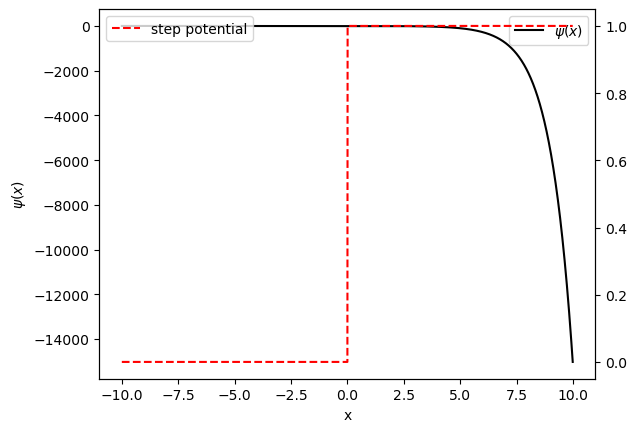

In [13]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$\psi(x)$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label='step potential')

ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()
ax2.legend()

In [14]:
# Initial wave function
psi_0, psi_1 = 0, -1.0*epsilon

In [15]:
# Approximate wave function
E = 1.1
psis = np.zeros(len(xs))

In [16]:
psis = numerov(E, inverse_step)
pots = np.array([inverse_step(x) for x in xs])

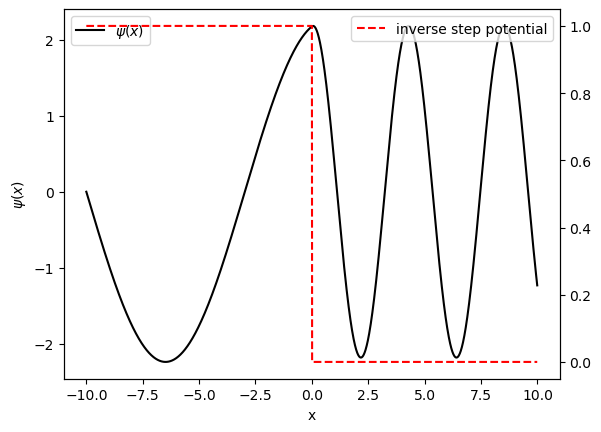

In [17]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$\psi(x)$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label='inverse step potential')

ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()
ax2.legend()

# Smooth step potential

However, the step potential is not capturing the change in the amplitude of the waves in the two regions. This is because of the "abruptness" of the potential. In nature, nothing is abrupt. So let us substitute the step potential with a more realistic potential


$$
V(x) = V_0 \frac{1}{1 + \exp\left(-\frac{x}{T}\right)},
$$

where $T$ is a fictitious temperature with units in position.

In [18]:
# globals
T = 1
V0 = 1

In [19]:
def smooth_step(x):
    return V0/(1 + np.exp(-1.0*x/T))

In [20]:
pots = np.array([smooth_step(x) for x in xs])

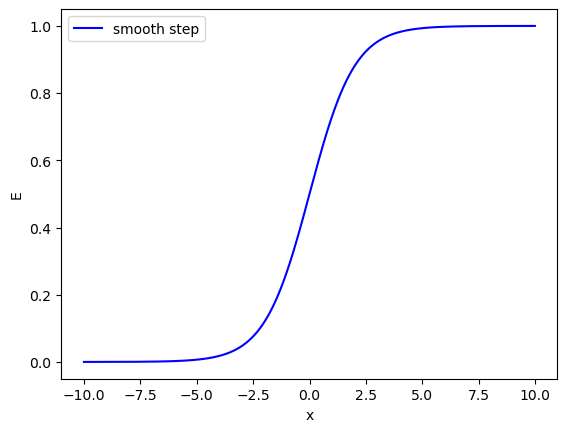

In [21]:
fig, ax = plt.subplots()
ax.plot(xs, pots, 'b-', label='smooth step')
ax.set_xlabel('x')
ax.set_ylabel('E')
ax.legend()

In [22]:
# Initial wave function
psi_0, psi_1 = 0, 1.0*epsilon

In [23]:
# Approximate wave function
E = 0.5
psis = np.zeros(len(xs))

In [24]:
psis = numerov(E, smooth_step)
pots = np.array([smooth_step(x) for x in xs])

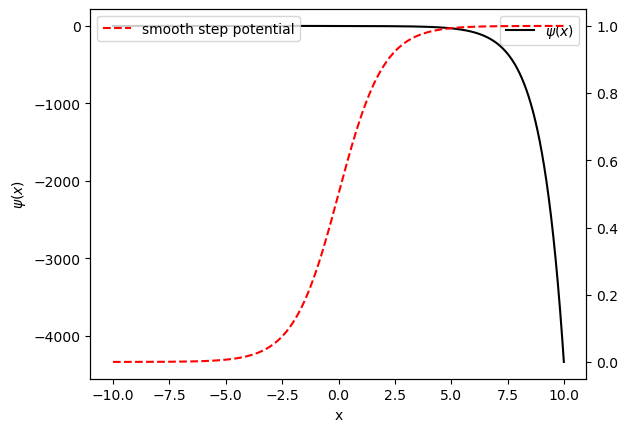

In [25]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$\psi(x)$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label='smooth step potential')

ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()
ax2.legend()

In [26]:
def inverse_smooth_step(x):
    return smooth_step(-1.0*x)

In [27]:
pots = np.array([inverse_smooth_step(x) for x in xs])

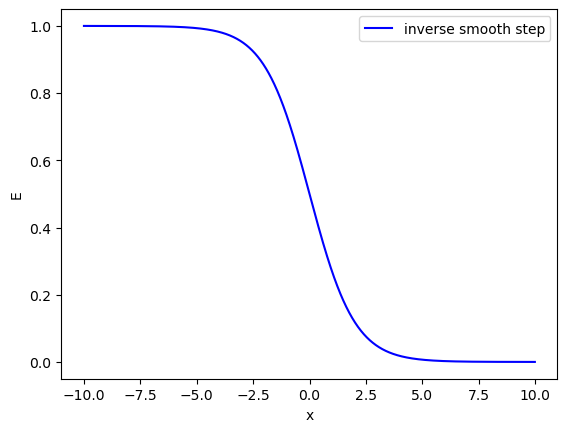

In [28]:
fig, ax = plt.subplots()
ax.plot(xs, pots, 'b-', label='inverse smooth step')
ax.set_xlabel('x')
ax.set_ylabel('E')
ax.legend()

In [29]:
# Initial wave function
psi_0, psi_1 = 0, 1.0*epsilon

In [30]:
# Approximate wave function
E = 1.5
psis = np.zeros(len(xs))

In [31]:
psis = numerov(E, inverse_smooth_step)
pots = np.array([inverse_smooth_step(x) for x in xs])

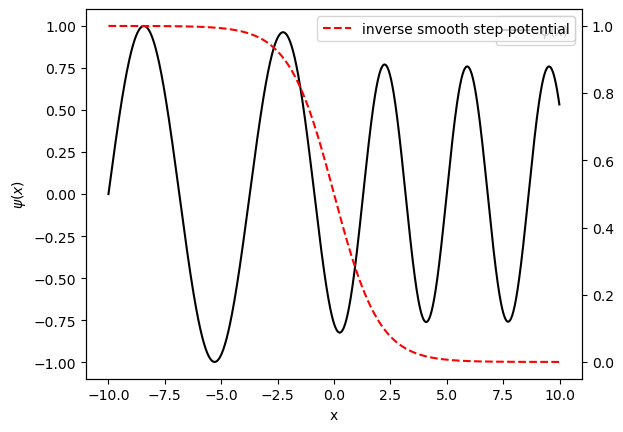

In [32]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$\psi(x)$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label='inverse smooth step potential')

ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()
ax2.legend()

In [33]:
# Initial wave function
psi_0, psi_1 = 0, 1.0*epsilon

In [34]:
# Approximate wave function
E = 0.8
psis = np.zeros(len(xs))

In [35]:
psis = numerov(E, inverse_smooth_step)
pots = np.array([inverse_smooth_step(x) for x in xs])

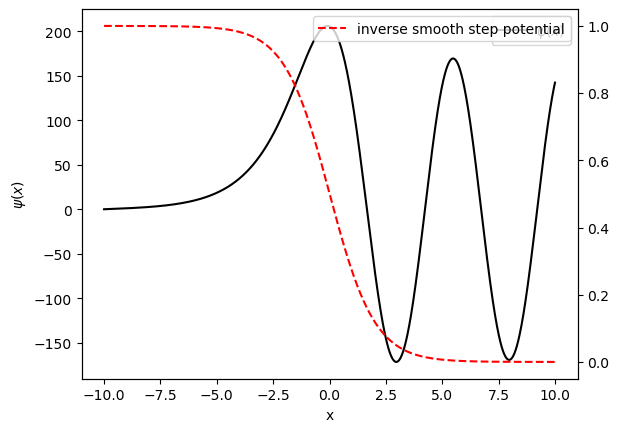

In [36]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$\psi(x)$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label='inverse smooth step potential')

ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()
ax2.legend()

In [56]:
# globals
well_width = 10.0

In [57]:
def finite_well(x):
    halfwidth = well_width/2.0
    return inverse_smooth_step(x+halfwidth) + smooth_step(x-halfwidth)

In [58]:
pots = np.array([finite_well(x) for x in xs])

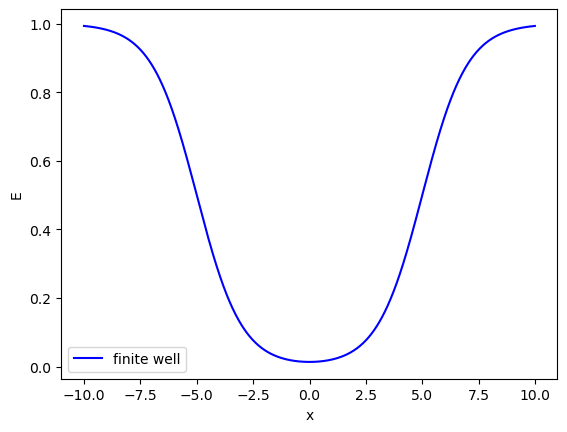

In [59]:
fig, ax = plt.subplots()
ax.plot(xs, pots, 'b-', label='finite well')
ax.set_xlabel('x')
ax.set_ylabel('E')
ax.legend()

In [54]:
# Initial wave function
psi_0, psi_1 = 0, 1.0*epsilon

In [55]:
# Approximate wave function
E = 0.8
psis = np.zeros(len(xs))

In [61]:
psis = numerov(E, finite_well)
pots = np.array([finite_well(x) for x in xs])

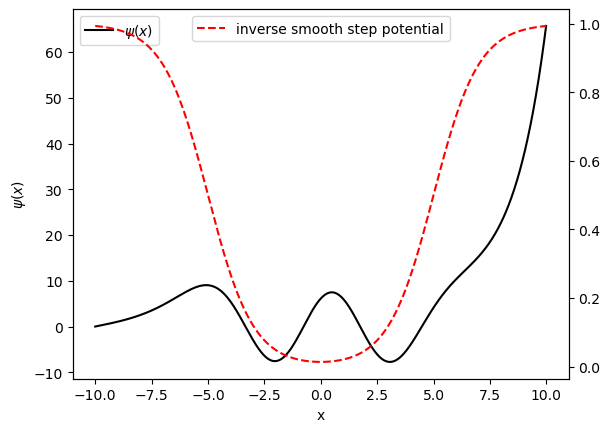

In [62]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$\psi(x)$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label='inverse smooth step potential')

ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()
ax2.legend()